Current working directory:
/home/aluoch/smart-waste-classifier/notebooks
Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 60s 189ms/step - accuracy: 0.3581 - loss: 1.8034 - val_accuracy: 0.4961 - val_loss: 1.4731
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 181ms/step - accuracy: 0.5142 - loss: 1.3918 - val_accuracy: 0.5565 - val_loss: 1.3053
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.5739 - loss: 1.2317 - val_accuracy: 0.5998 - val_loss: 1.2116
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 57s 185ms/step - accuracy: 0.6122 - loss: 1.1339 - val_accuracy: 0.6104 - val_loss: 1.1654
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 57s 186ms/step - accuracy: 0.6362 - loss: 1.0667 - val_accuracy: 0.6308 - val_loss: 1.1147
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 58s 188ms/step - accuracy: 0.6669 - loss: 0.9911 - val_accuracy: 0.6259 - val_loss: 1.1197
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 183ms/step - accuracy: 0.6873 - loss: 0.9311 - val_accuracy: 0.6679 - val_loss: 1.0495
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/step - accuracy: 0.7041 - loss: 0

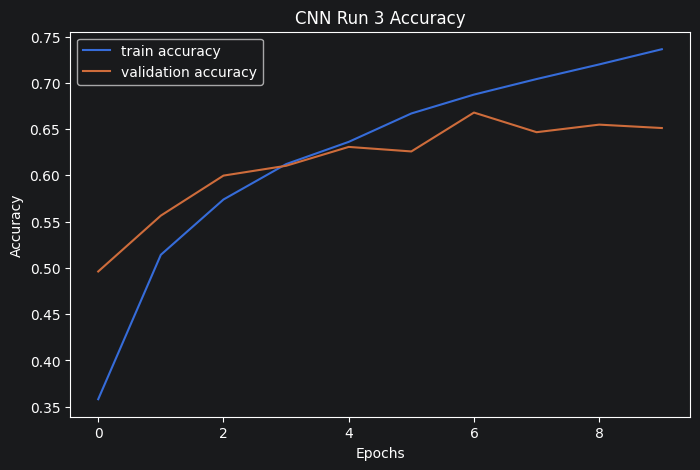

Saved CNN run 3 loss figure successfully!


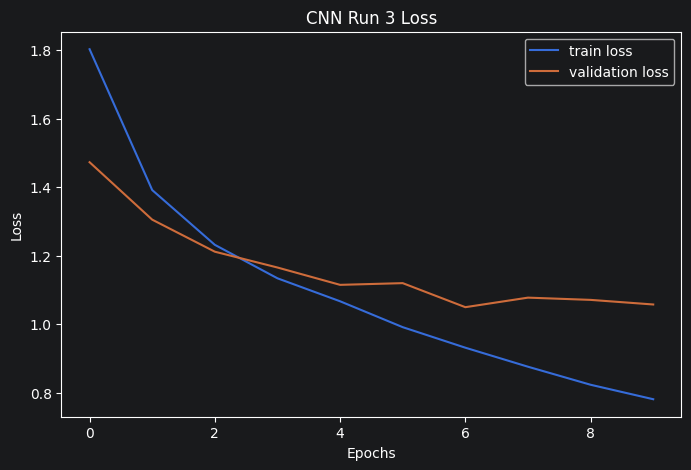

CNN run 3 model saved successfully!


In [4]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("Current working directory:")
print(os.getcwd())

# Dataset loading
data_dir = "../data/standardized_256"

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Create output folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1)
])

# Build CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Training timer
start_time = time.time()

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# End timer
end_time = time.time()

print("Training time:", end_time - start_time, "seconds")

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title("CNN Run 3 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/cnn_run3_accuracy.png")
print("Saved CNN run 3 accuracy image successfully!")

plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title("CNN Run 3 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/cnn_run3_loss.png")
print("Saved CNN run 3 loss figure successfully!")

plt.show()

# Save model
model.save("../models/cnn_run3.keras")
print("CNN run 3 model saved successfully!")